# Install dependencies

In [1]:
import sys
import subprocess
import importlib.util

packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "PIL": "pillow",
    "tqdm": "tqdm",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "hdbscan": "hdbscan",
}

missing = [pip_name for module_name, pip_name in packages.items() if importlib.util.find_spec(module_name) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

print("Dependency check completed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 76.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 6.3 MB/s  0:00:00m 6.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 77.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [hdbscan]━━━ 5/6 [hdbscan]atplotlib]
Dependency check completed.


# Imports

In [2]:
from pathlib import Path
from PIL import Image, ImageOps, ImageDraw, ImageFont
from datetime import datetime
from collections import defaultdict
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import json
import os
import sys
import platform
import warnings
import math
import shutil
import matplotlib.pyplot as plt

try:
    import hdbscan
    HDBSCAN_BACKEND = "hdbscan"
except Exception:
    hdbscan = None
    HDBSCAN_BACKEND = "sklearn"

if HDBSCAN_BACKEND == "sklearn":
    try:
        from sklearn.cluster import HDBSCAN
    except Exception as exc:
        raise RuntimeError(
            "Neither the hdbscan package nor sklearn.cluster.HDBSCAN is available. "
            "Install hdbscan or upgrade scikit-learn."
        ) from exc

Image.MAX_IMAGE_PIXELS = 300_000_000
warnings.simplefilter("error", Image.DecompressionBombWarning)

print(f"Imports completed. HDBSCAN backend: {HDBSCAN_BACKEND}")

Imports completed. HDBSCAN backend: hdbscan


# Configuration

In [3]:
PROJECT_DIR = Path("./anime_character_pipeline").expanduser().resolve()
PREVIOUS_RUN_DIR = None

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = PROJECT_DIR / "runs" / f"04_hdbscan_clustering_{RUN_ID}"

REPORTS_DIR = RUN_DIR / "reports"
TABLES_DIR = RUN_DIR / "tables"
ARRAYS_DIR = RUN_DIR / "arrays"
FIGURES_DIR = RUN_DIR / "figures"
CONTACT_SHEETS_DIR = RUN_DIR / "contact_sheets"
CLUSTER_METADATA_DIR = RUN_DIR / "cluster_metadata"

for directory in [
    RUN_DIR,
    REPORTS_DIR,
    TABLES_DIR,
    ARRAYS_DIR,
    FIGURES_DIR,
    CONTACT_SHEETS_DIR,
    CLUSTER_METADATA_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

EMBEDDING_FILE_NAME = "ccip_embeddings_l2.npy"
MANIFEST_FILE_NAME = "successful_embedding_manifest.csv"

MIN_CLUSTER_SIZE = 5
MIN_SAMPLES = 4
CLUSTER_SELECTION_METHOD = "eom"
METRIC = "euclidean"

LOW_PROBABILITY_THRESHOLD = 0.35
HIGH_OUTLIER_QUANTILE = 0.95
MIN_CLUSTER_IMAGES_FOR_CONTACT_SHEET = 2

CONTACT_SHEET_THUMB_SIZE = 180
CONTACT_SHEET_COLUMNS = 6
CONTACT_SHEET_REPRESENTATIVE_COUNT = 18
CONTACT_SHEET_BOUNDARY_COUNT = 6
MAX_CONTACT_SHEETS = 250

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print(f"Project directory: {PROJECT_DIR}")
print(f"Run directory: {RUN_DIR}")
print(f"Backend: {HDBSCAN_BACKEND}")
print(f"min_cluster_size: {MIN_CLUSTER_SIZE}")
print(f"min_samples: {MIN_SAMPLES}")

Project directory: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline
Run directory: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927
Backend: hdbscan
min_cluster_size: 5
min_samples: 4


# Locate previous embedding run


In [4]:
def find_latest_embedding_run(project_dir):
    runs_dir = Path(project_dir) / "runs"
    candidates = sorted(
        [p for p in runs_dir.glob("03_ccip_embeddings_*") if p.is_dir()],
        key=lambda p: p.name,
    )

    valid_candidates = []
    for candidate in candidates:
        embeddings_path = candidate / "arrays" / EMBEDDING_FILE_NAME
        manifest_path = candidate / "tables" / MANIFEST_FILE_NAME
        if embeddings_path.exists() and manifest_path.exists():
            valid_candidates.append(candidate)

    if not valid_candidates:
        raise FileNotFoundError(
            f"No valid 03_ccip_embeddings_* run was found in {runs_dir}. "
            f"Expected files: arrays/{EMBEDDING_FILE_NAME} and tables/{MANIFEST_FILE_NAME}."
        )

    return valid_candidates[-1]


PREVIOUS_RUN_DIR = globals().get("PREVIOUS_RUN_DIR", None)

if PREVIOUS_RUN_DIR is None:
    PREVIOUS_RUN_DIR = find_latest_embedding_run(PROJECT_DIR)
else:
    PREVIOUS_RUN_DIR = Path(PREVIOUS_RUN_DIR).expanduser().resolve()

embeddings_path = PREVIOUS_RUN_DIR / "arrays" / EMBEDDING_FILE_NAME
manifest_path = PREVIOUS_RUN_DIR / "tables" / MANIFEST_FILE_NAME

if not embeddings_path.exists():
    raise FileNotFoundError(f"Embedding matrix not found: {embeddings_path}")

if not manifest_path.exists():
    raise FileNotFoundError(f"Embedding manifest not found: {manifest_path}")

embedding_manifest_df = pd.read_csv(manifest_path)
embeddings = np.load(embeddings_path).astype(np.float32)

print(f"Previous embedding run: {PREVIOUS_RUN_DIR}")
print(f"Embedding matrix shape: {embeddings.shape}")
print(f"Manifest rows: {len(embedding_manifest_df)}")

Previous embedding run: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/03_ccip_embeddings_20260523_204425
Embedding matrix shape: (15705, 768)
Manifest rows: 15705


# Consistency checks for embeddings and manifest

In [5]:
required_columns = {
    "embedding_row",
    "crop_path",
    "source_path",
    "relative_path",
    "selected_region_type",
    "needs_review",
    "review_reason",
}

missing_columns = sorted(required_columns.difference(set(embedding_manifest_df.columns)))

if missing_columns:
    raise ValueError(f"The embedding manifest is missing required columns: {missing_columns}")

if embeddings.ndim != 2:
    raise ValueError(f"Expected a 2D embedding matrix, got shape {embeddings.shape}.")

if len(embedding_manifest_df) != embeddings.shape[0]:
    raise ValueError(
        "Manifest row count does not match embedding matrix row count. "
        f"Manifest rows: {len(embedding_manifest_df)}. Embedding rows: {embeddings.shape[0]}."
    )

embedding_manifest_df = embedding_manifest_df.sort_values("embedding_row").reset_index(drop=True)

expected_rows = list(range(len(embedding_manifest_df)))
actual_rows = embedding_manifest_df["embedding_row"].astype(int).tolist()

if actual_rows != expected_rows:
    raise ValueError("embedding_row values are not consecutive after sorting.")

if np.isnan(embeddings).any():
    raise ValueError("Embedding matrix contains NaN values.")

if np.isinf(embeddings).any():
    raise ValueError("Embedding matrix contains infinite values.")

embedding_norms = np.linalg.norm(embeddings, axis=1)

norm_diagnostics = {
    "norm_min": float(embedding_norms.min()),
    "norm_max": float(embedding_norms.max()),
    "norm_mean": float(embedding_norms.mean()),
    "norm_std": float(embedding_norms.std()),
}

print(norm_diagnostics)

if not np.all(np.isfinite(embedding_norms)):
    raise ValueError("Embedding norms contain non-finite values.")

{'norm_min': 0.9999998807907104, 'norm_max': 1.0000001192092896, 'norm_mean': 1.0, 'norm_std': 3.748063548414393e-08}


# Helper functions

In [6]:
def now_iso():
    return datetime.now().astimezone().isoformat(timespec="seconds")


def safe_bool_series(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.lower().isin(["true", "1", "yes", "y"])


def sanitize_folder_name(value, fallback):
    value = str(value).strip()
    if not value:
        value = fallback

    forbidden = '<>:"/\\|?*'
    cleaned = "".join("_" if ch in forbidden else ch for ch in value)
    cleaned = "".join(ch if ch.isprintable() else "_" for ch in cleaned)
    cleaned = cleaned.strip().strip(".")
    cleaned = "_".join(cleaned.split())

    if not cleaned:
        cleaned = fallback

    return cleaned[:120]


def compute_cluster_centroids(X, labels):
    centroids = {}

    for label in sorted(set(labels)):
        if label == -1:
            continue

        idx = np.where(labels == label)[0]
        if len(idx) == 0:
            continue

        centroid = X[idx].mean(axis=0)
        norm = np.linalg.norm(centroid)

        if norm > 0:
            centroid = centroid / norm

        centroids[int(label)] = centroid.astype(np.float32)

    return centroids


def euclidean_distance_to_centroid(X, centroid):
    return np.linalg.norm(X - centroid.reshape(1, -1), axis=1)


def create_contact_sheet(image_paths, output_path, thumb_size=180, columns=6, title=None):
    image_paths = [Path(p) for p in image_paths if pd.notna(p) and Path(p).exists()]

    if not image_paths:
        return False

    rows = int(math.ceil(len(image_paths) / columns))
    title_height = 34 if title else 0

    sheet_width = columns * thumb_size
    sheet_height = rows * thumb_size + title_height

    sheet = Image.new("RGB", (sheet_width, sheet_height), "white")
    draw = ImageDraw.Draw(sheet)

    if title:
        draw.rectangle((0, 0, sheet_width, title_height), fill=(245, 245, 245))
        draw.text((10, 9), title[:180], fill=(20, 20, 20))

    for idx, path in enumerate(image_paths):
        try:
            with Image.open(path) as img:
                img = ImageOps.exif_transpose(img.convert("RGB"))
                img.thumbnail((thumb_size, thumb_size), Image.Resampling.LANCZOS)

                x = (idx % columns) * thumb_size + (thumb_size - img.width) // 2
                y = title_height + (idx // columns) * thumb_size + (thumb_size - img.height) // 2

                sheet.paste(img, (x, y))
        except Exception:
            continue

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    sheet.save(output_path, format="JPEG", quality=92, optimize=True)
    return True


def sample_representative_and_boundary_rows(cluster_df, representative_count, boundary_count):
    cluster_df = cluster_df.sort_values("distance_to_centroid", ascending=True).copy()

    representative = cluster_df.head(representative_count)

    boundary = cluster_df.sort_values("distance_to_centroid", ascending=False).head(boundary_count)

    sampled = pd.concat([representative, boundary], axis=0)
    sampled = sampled.drop_duplicates(subset=["embedding_row"], keep="first")
    sampled = sampled.sort_values("distance_to_centroid", ascending=True)

    return sampled


print("Helper functions loaded.")

Helper functions loaded.


# Fit HDBSCAN clustering

In [7]:
if HDBSCAN_BACKEND == "hdbscan":
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric=METRIC,
        cluster_selection_method=CLUSTER_SELECTION_METHOD,
        prediction_data=False,
        core_dist_n_jobs=max(1, min(8, os.cpu_count() or 1)),
    )

    labels = clusterer.fit_predict(embeddings).astype(int)

    probabilities = getattr(clusterer, "probabilities_", None)
    if probabilities is None:
        probabilities = np.ones(len(labels), dtype=np.float32)
    probabilities = np.asarray(probabilities, dtype=np.float32)

    outlier_scores = getattr(clusterer, "outlier_scores_", None)
    if outlier_scores is None:
        outlier_scores = np.where(labels == -1, 1.0, 1.0 - probabilities).astype(np.float32)
    outlier_scores = np.asarray(outlier_scores, dtype=np.float32)

else:
    clusterer = HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric=METRIC,
        cluster_selection_method=CLUSTER_SELECTION_METHOD,
    )

    labels = clusterer.fit_predict(embeddings).astype(int)

    probabilities = getattr(clusterer, "probabilities_", None)
    if probabilities is None:
        probabilities = np.ones(len(labels), dtype=np.float32)
    probabilities = np.asarray(probabilities, dtype=np.float32)

    outlier_scores = np.where(labels == -1, 1.0, 1.0 - probabilities).astype(np.float32)

if len(labels) != embeddings.shape[0]:
    raise ValueError("Cluster label count does not match embedding row count.")

if len(probabilities) != embeddings.shape[0]:
    raise ValueError("Probability count does not match embedding row count.")

if len(outlier_scores) != embeddings.shape[0]:
    raise ValueError("Outlier score count does not match embedding row count.")

cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
noise_count = int(np.sum(labels == -1))

print(f"Estimated clusters: {cluster_count}")
print(f"Noise points: {noise_count}")
print(f"Clustered points: {len(labels) - noise_count}")


Estimated clusters: 188
Noise points: 9138
Clustered points: 6567


# Create clustering manifest

In [8]:
cluster_manifest_df = embedding_manifest_df.copy()

cluster_manifest_df["cluster_label"] = labels
cluster_manifest_df["cluster_probability"] = probabilities
cluster_manifest_df["outlier_score"] = outlier_scores

cluster_manifest_df["needs_review"] = safe_bool_series(cluster_manifest_df["needs_review"])

finite_outlier_scores = cluster_manifest_df["outlier_score"].replace([np.inf, -np.inf], np.nan).dropna()

if finite_outlier_scores.empty:
    high_outlier_threshold = 1.0
else:
    high_outlier_threshold = float(finite_outlier_scores.quantile(HIGH_OUTLIER_QUANTILE))

cluster_manifest_df["is_noise"] = cluster_manifest_df["cluster_label"].eq(-1)
cluster_manifest_df["is_low_probability"] = cluster_manifest_df["cluster_probability"].lt(LOW_PROBABILITY_THRESHOLD)
cluster_manifest_df["is_high_outlier"] = cluster_manifest_df["outlier_score"].gt(high_outlier_threshold)

cluster_manifest_df["cluster_review_reason"] = ""

cluster_manifest_df.loc[
    cluster_manifest_df["is_noise"],
    "cluster_review_reason"
] = "hdbscan_noise"

cluster_manifest_df.loc[
    ~cluster_manifest_df["is_noise"] & cluster_manifest_df["is_low_probability"],
    "cluster_review_reason"
] = "low_cluster_membership_probability"

cluster_manifest_df.loc[
    ~cluster_manifest_df["is_noise"] & ~cluster_manifest_df["is_low_probability"] & cluster_manifest_df["is_high_outlier"],
    "cluster_review_reason"
] = "high_local_outlier_score"

cluster_manifest_df.loc[
    cluster_manifest_df["needs_review"] & cluster_manifest_df["cluster_review_reason"].eq(""),
    "cluster_review_reason"
] = "previous_crop_review_flag"

cluster_manifest_df["requires_manual_review"] = (
    cluster_manifest_df["is_noise"] |
    cluster_manifest_df["is_low_probability"] |
    cluster_manifest_df["is_high_outlier"] |
    cluster_manifest_df["needs_review"]
)

cluster_manifest_df["cluster_folder_stub"] = cluster_manifest_df["cluster_label"].map(
    lambda x: "_needs_review_noise" if int(x) == -1 else f"cluster_{int(x):05d}_unknown"
)

print(f"Rows in cluster manifest: {len(cluster_manifest_df)}")
print(f"Manual review rows: {int(cluster_manifest_df['requires_manual_review'].sum())}")
print(f"High outlier threshold: {high_outlier_threshold:.6f}")

Rows in cluster manifest: 15705
Manual review rows: 10720
High outlier threshold: 0.697847


# Compute centroid distances and cluster diagnostics 

In [9]:
centroids = compute_cluster_centroids(embeddings, labels)

distance_to_centroid = np.full(embeddings.shape[0], np.nan, dtype=np.float32)

for label, centroid in centroids.items():
    idx = np.where(labels == label)[0]
    distance_to_centroid[idx] = euclidean_distance_to_centroid(embeddings[idx], centroid).astype(np.float32)

cluster_manifest_df["distance_to_centroid"] = distance_to_centroid

cluster_summary_rows = []

for label in sorted(set(labels)):
    cluster_df = cluster_manifest_df[cluster_manifest_df["cluster_label"].eq(label)].copy()

    if cluster_df.empty:
        continue

    is_noise = int(label) == -1
    folder_stub = "_needs_review_noise" if is_noise else f"cluster_{int(label):05d}_unknown"

    distances = cluster_df["distance_to_centroid"].replace([np.inf, -np.inf], np.nan).dropna()
    probabilities_cluster = cluster_df["cluster_probability"].replace([np.inf, -np.inf], np.nan).dropna()
    outliers_cluster = cluster_df["outlier_score"].replace([np.inf, -np.inf], np.nan).dropna()

    cluster_summary_rows.append({
        "cluster_label": int(label),
        "cluster_folder_stub": folder_stub,
        "is_noise_cluster": bool(is_noise),
        "image_count": int(len(cluster_df)),
        "requires_review_count": int(cluster_df["requires_manual_review"].sum()),
        "requires_review_share": float(cluster_df["requires_manual_review"].mean()),
        "mean_probability": float(probabilities_cluster.mean()) if not probabilities_cluster.empty else np.nan,
        "median_probability": float(probabilities_cluster.median()) if not probabilities_cluster.empty else np.nan,
        "min_probability": float(probabilities_cluster.min()) if not probabilities_cluster.empty else np.nan,
        "mean_outlier_score": float(outliers_cluster.mean()) if not outliers_cluster.empty else np.nan,
        "median_outlier_score": float(outliers_cluster.median()) if not outliers_cluster.empty else np.nan,
        "max_outlier_score": float(outliers_cluster.max()) if not outliers_cluster.empty else np.nan,
        "mean_distance_to_centroid": float(distances.mean()) if not distances.empty else np.nan,
        "median_distance_to_centroid": float(distances.median()) if not distances.empty else np.nan,
        "max_distance_to_centroid": float(distances.max()) if not distances.empty else np.nan,
        "head_crop_count": int(cluster_df["selected_region_type"].eq("head").sum()) if "selected_region_type" in cluster_df.columns else 0,
        "person_crop_count": int(cluster_df["selected_region_type"].eq("person").sum()) if "selected_region_type" in cluster_df.columns else 0,
        "full_image_count": int(cluster_df["selected_region_type"].astype(str).str.contains("full_image", na=False).sum()) if "selected_region_type" in cluster_df.columns else 0,
    })

cluster_summary_df = pd.DataFrame(cluster_summary_rows)

cluster_summary_df = cluster_summary_df.sort_values(
    ["is_noise_cluster", "image_count", "cluster_label"],
    ascending=[True, False, True],
).reset_index(drop=True)

print(f"Cluster summary rows: {len(cluster_summary_df)}")
cluster_summary_df.head(20)

Cluster summary rows: 189


,cluster_label,cluster_folder_stub,is_noise_cluster,image_count,requires_review_count,requires_review_share,mean_probability,median_probability,min_probability,mean_outlier_score,median_outlier_score,max_outlier_score,mean_distance_to_centroid,median_distance_to_centroid,max_distance_to_centroid,head_crop_count,person_crop_count,full_image_count
0,183,cluster_00183_unknown,False,505,137,0.271287,0.965135,0.985834,0.879650,0.208207,0.228702,0.311779,0.519082,0.517550,0.794200,503,0,2
1,169,cluster_00169_unknown,False,352,88,0.250000,0.764622,0.749291,0.638884,0.235378,0.250709,0.361116,0.487441,0.482914,0.919754,351,1,0
2,171,cluster_00171_unknown,False,344,76,0.220930,0.786273,0.781991,0.650009,0.213727,0.218009,0.349991,0.468240,0.469211,0.672717,344,0,0
3,172,cluster_00172_unknown,False,240,58,0.241667,0.727940,0.702855,0.591403,0.272060,0.297145,0.408597,0.462398,0.457261,0.869524,239,1,0
4,181,cluster_00181_unknown,False,233,41,0.175966,0.978279,1.000000,0.891025,0.153851,0.166938,0.276708,0.437579,0.437098,0.605265,233,0,0
5,110,cluster_00110_unknown,False,217,47,0.216590,0.963787,1.000000,0.819226,0.366580,0.410531,0.560615,0.498742,0.477553,0.985564,214,3,0
6,170,cluster_00170_unknown,False,160,42,0.262500,0.684038,0.678100,0.438947,0.315962,0.321900,0.561053,0.390884,0.359750,0.901582,159,1,0
7,139,cluster_00139_unknown,False,141,44,0.312057,0.933778,0.977621,0.758721,0.321362,0.368808,0.510139,0.424037,0.418415,0.676775,141,0,0
8,177,cluster_00177_unknown,False,138,48,0.347826,0.902539,0.900965,0.753906,0.161271,0.172290,0.307392,0.431598,0.428599,0.665172,137,1,0
9,148,cluster_00148_unknown,False,129,45,0.348837,0.781944,0.759790,0.631870,0.218056,0.240210,0.368130,0.466240,0.461290,0.774758,129,0,0


# Save clustering arrays and tables


In [10]:
labels_path = ARRAYS_DIR / "cluster_labels.npy"
probabilities_path = ARRAYS_DIR / "cluster_probabilities.npy"
outlier_scores_path = ARRAYS_DIR / "outlier_scores.npy"
centroids_path = ARRAYS_DIR / "cluster_centroids.npz"

cluster_manifest_path = TABLES_DIR / "cluster_manifest.csv"
cluster_summary_path = TABLES_DIR / "cluster_summary.csv"
review_manifest_path = TABLES_DIR / "manual_review_manifest.csv"
noise_manifest_path = TABLES_DIR / "noise_manifest.csv"

np.save(labels_path, labels)
np.save(probabilities_path, probabilities)
np.save(outlier_scores_path, outlier_scores)

np.savez_compressed(
    centroids_path,
    **{f"cluster_{label}": centroid for label, centroid in centroids.items()}
)

cluster_manifest_df.to_csv(cluster_manifest_path, index=False)
cluster_summary_df.to_csv(cluster_summary_path, index=False)

manual_review_df = cluster_manifest_df[cluster_manifest_df["requires_manual_review"]].copy()
noise_df = cluster_manifest_df[cluster_manifest_df["is_noise"]].copy()

manual_review_df.to_csv(review_manifest_path, index=False)
noise_df.to_csv(noise_manifest_path, index=False)

print(f"Saved labels: {labels_path}")
print(f"Saved probabilities: {probabilities_path}")
print(f"Saved outlier scores: {outlier_scores_path}")
print(f"Saved cluster manifest: {cluster_manifest_path}")
print(f"Saved cluster summary: {cluster_summary_path}")
print(f"Saved manual review manifest: {review_manifest_path}")

Saved labels: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/arrays/cluster_labels.npy
Saved probabilities: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/arrays/cluster_probabilities.npy
Saved outlier scores: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/arrays/outlier_scores.npy
Saved cluster manifest: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/tables/cluster_manifest.csv
Saved cluster summary: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/tables/cluster_summary.csv
S

# Plot cluster size distribution

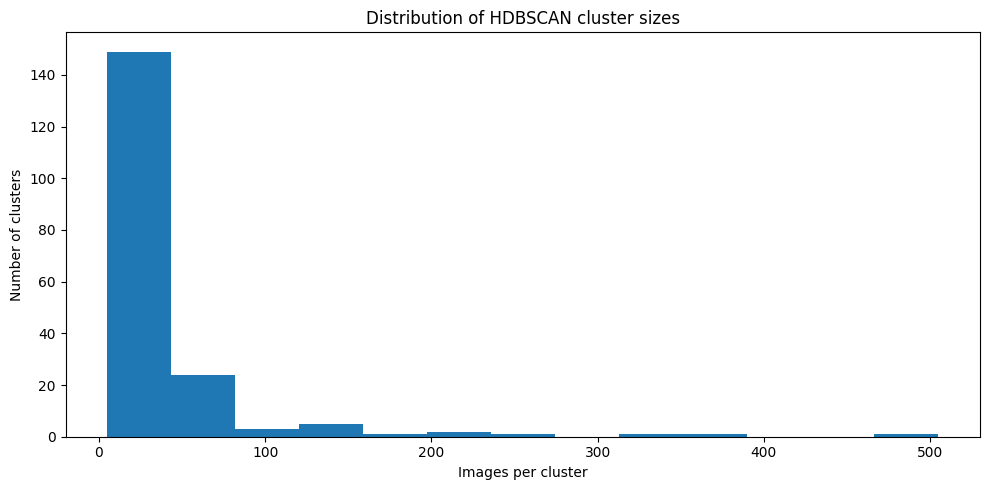

/home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/figures/cluster_size_distribution.png


In [11]:
non_noise_summary_df = cluster_summary_df[~cluster_summary_df["is_noise_cluster"]].copy()

plt.figure(figsize=(10, 5))

if non_noise_summary_df.empty:
    plt.text(0.5, 0.5, "No non-noise clusters were detected.", ha="center", va="center")
    plt.axis("off")
else:
    sizes = non_noise_summary_df["image_count"].to_numpy()
    plt.hist(sizes, bins=min(50, max(5, int(np.sqrt(len(sizes))))))
    plt.xlabel("Images per cluster")
    plt.ylabel("Number of clusters")
    plt.title("Distribution of HDBSCAN cluster sizes")

cluster_size_plot_path = FIGURES_DIR / "cluster_size_distribution.png"
plt.tight_layout()
plt.savefig(cluster_size_plot_path, dpi=160)
plt.show()

print(cluster_size_plot_path)


# Plot probability and outlier-score distributions

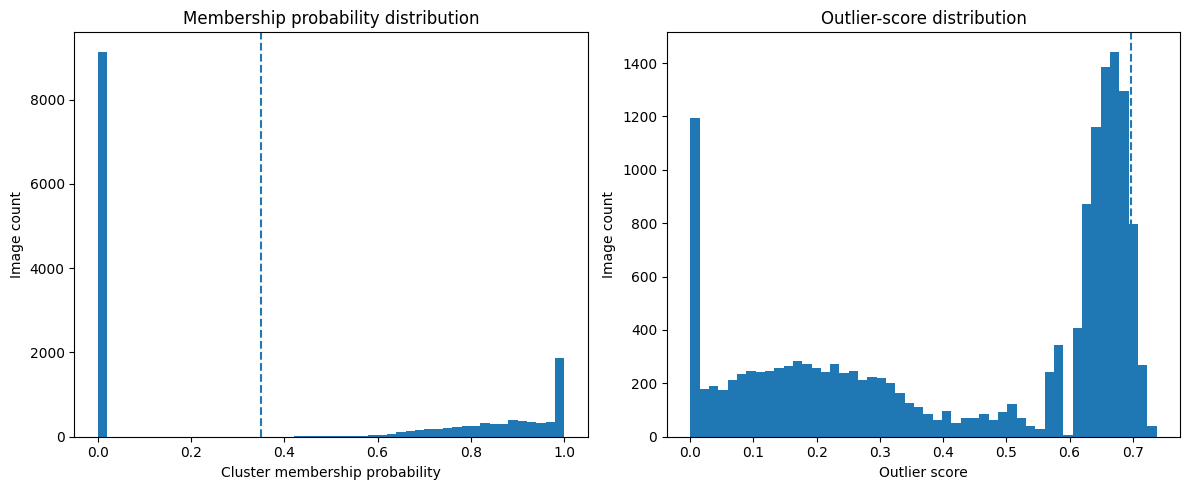

/home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/figures/probability_outlier_distribution.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(cluster_manifest_df["cluster_probability"].dropna().to_numpy(), bins=50)
axes[0].axvline(LOW_PROBABILITY_THRESHOLD, linestyle="--")
axes[0].set_xlabel("Cluster membership probability")
axes[0].set_ylabel("Image count")
axes[0].set_title("Membership probability distribution")

axes[1].hist(cluster_manifest_df["outlier_score"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(), bins=50)
axes[1].axvline(high_outlier_threshold, linestyle="--")
axes[1].set_xlabel("Outlier score")
axes[1].set_ylabel("Image count")
axes[1].set_title("Outlier-score distribution")

probability_outlier_plot_path = FIGURES_DIR / "probability_outlier_distribution.png"
plt.tight_layout()
plt.savefig(probability_outlier_plot_path, dpi=160)
plt.show()

print(probability_outlier_plot_path)

# Create representative contact sheets by cluster

In [13]:
contact_sheet_rows = []

eligible_clusters_df = cluster_summary_df[
    (~cluster_summary_df["is_noise_cluster"]) &
    (cluster_summary_df["image_count"] >= MIN_CLUSTER_IMAGES_FOR_CONTACT_SHEET)
].copy()

eligible_clusters_df = eligible_clusters_df.sort_values(
    ["image_count", "mean_probability"],
    ascending=[False, False],
).head(MAX_CONTACT_SHEETS)

for _, cluster_row in tqdm(
    eligible_clusters_df.iterrows(),
    total=len(eligible_clusters_df),
    desc="Creating cluster contact sheets",
):
    label = int(cluster_row["cluster_label"])
    folder_stub = cluster_row["cluster_folder_stub"]

    this_cluster_df = cluster_manifest_df[
        cluster_manifest_df["cluster_label"].eq(label)
    ].copy()

    sampled_df = sample_representative_and_boundary_rows(
        this_cluster_df,
        representative_count=CONTACT_SHEET_REPRESENTATIVE_COUNT,
        boundary_count=CONTACT_SHEET_BOUNDARY_COUNT,
    )

    image_paths = sampled_df["crop_path"].dropna().tolist()
    output_path = CONTACT_SHEETS_DIR / f"{folder_stub}.jpg"

    title = (
        f"{folder_stub} | n={len(this_cluster_df)} | "
        f"mean_p={cluster_row['mean_probability']:.3f}"
    )

    created = create_contact_sheet(
        image_paths=image_paths,
        output_path=output_path,
        thumb_size=CONTACT_SHEET_THUMB_SIZE,
        columns=CONTACT_SHEET_COLUMNS,
        title=title,
    )

    contact_sheet_rows.append({
        "cluster_label": label,
        "cluster_folder_stub": folder_stub,
        "image_count": int(len(this_cluster_df)),
        "sampled_image_count": int(len(image_paths)),
        "created": bool(created),
        "contact_sheet_path": output_path.as_posix() if created else None,
    })

contact_sheets_df = pd.DataFrame(contact_sheet_rows)
contact_sheets_path = TABLES_DIR / "cluster_contact_sheets.csv"
contact_sheets_df.to_csv(contact_sheets_path, index=False)

contact_sheets_df.head(20)

Creating cluster contact sheets:   0%|          | 0/188 [00:00<?, ?it/s]

,cluster_label,cluster_folder_stub,image_count,sampled_image_count,created,contact_sheet_path
0,183,cluster_00183_unknown,505,24,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
1,169,cluster_00169_unknown,352,24,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
2,171,cluster_00171_unknown,344,24,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
3,172,cluster_00172_unknown,240,24,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
4,181,cluster_00181_unknown,233,24,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
5,110,cluster_00110_unknown,217,24,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
6,170,cluster_00170_unknown,160,24,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
7,139,cluster_00139_unknown,141,24,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
8,177,cluster_00177_unknown,138,24,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
9,148,cluster_00148_unknown,129,24,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...


# Create noise and review contact sheets


In [14]:
special_sheet_rows = []

special_groups = {
    "noise_samples": cluster_manifest_df[cluster_manifest_df["is_noise"]].copy(),
    "low_probability_samples": cluster_manifest_df[
        (~cluster_manifest_df["is_noise"]) & cluster_manifest_df["is_low_probability"]
    ].copy(),
    "high_outlier_samples": cluster_manifest_df[
        (~cluster_manifest_df["is_noise"]) & cluster_manifest_df["is_high_outlier"]
    ].copy(),
    "manual_review_samples": cluster_manifest_df[
        cluster_manifest_df["requires_manual_review"]
    ].copy(),
}

for name, group in special_groups.items():
    if group.empty:
        special_sheet_rows.append({
            "sheet_name": name,
            "image_count": 0,
            "created": False,
            "contact_sheet_path": None,
        })
        continue

    if "distance_to_centroid" in group.columns:
        group = group.sort_values(
            ["outlier_score", "cluster_probability"],
            ascending=[False, True],
        )

    group = group.head(CONTACT_SHEET_REPRESENTATIVE_COUNT + CONTACT_SHEET_BOUNDARY_COUNT)

    output_path = CONTACT_SHEETS_DIR / f"_{name}.jpg"

    created = create_contact_sheet(
        image_paths=group["crop_path"].dropna().tolist(),
        output_path=output_path,
        thumb_size=CONTACT_SHEET_THUMB_SIZE,
        columns=CONTACT_SHEET_COLUMNS,
        title=f"{name} | n={len(special_groups[name])}",
    )

    special_sheet_rows.append({
        "sheet_name": name,
        "image_count": int(len(special_groups[name])),
        "sampled_image_count": int(len(group)),
        "created": bool(created),
        "contact_sheet_path": output_path.as_posix() if created else None,
    })

special_contact_sheets_df = pd.DataFrame(special_sheet_rows)
special_contact_sheets_path = TABLES_DIR / "special_contact_sheets.csv"
special_contact_sheets_df.to_csv(special_contact_sheets_path, index=False)

special_contact_sheets_df

,sheet_name,image_count,sampled_image_count,created,contact_sheet_path
0,noise_samples,9138,24.0,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
1,low_probability_samples,0,NaN,False,NaN
2,high_outlier_samples,0,NaN,False,NaN
3,manual_review_samples,10720,24.0,True,/home/ssparzival/Proyectos/GitHub/Automatic-Or...


# Write per-cluster metadata files


In [15]:
metadata_rows = []

for _, row in cluster_summary_df.iterrows():
    label = int(row["cluster_label"])
    folder_stub = row["cluster_folder_stub"]

    cluster_items_df = cluster_manifest_df[
        cluster_manifest_df["cluster_label"].eq(label)
    ].copy()

    metadata = {
        "cluster_label": label,
        "cluster_folder_stub": folder_stub,
        "is_noise_cluster": bool(row["is_noise_cluster"]),
        "image_count": int(row["image_count"]),
        "requires_review_count": int(row["requires_review_count"]),
        "requires_review_share": float(row["requires_review_share"]),
        "mean_probability": None if pd.isna(row["mean_probability"]) else float(row["mean_probability"]),
        "median_probability": None if pd.isna(row["median_probability"]) else float(row["median_probability"]),
        "min_probability": None if pd.isna(row["min_probability"]) else float(row["min_probability"]),
        "mean_outlier_score": None if pd.isna(row["mean_outlier_score"]) else float(row["mean_outlier_score"]),
        "median_outlier_score": None if pd.isna(row["median_outlier_score"]) else float(row["median_outlier_score"]),
        "max_outlier_score": None if pd.isna(row["max_outlier_score"]) else float(row["max_outlier_score"]),
        "mean_distance_to_centroid": None if pd.isna(row["mean_distance_to_centroid"]) else float(row["mean_distance_to_centroid"]),
        "median_distance_to_centroid": None if pd.isna(row["median_distance_to_centroid"]) else float(row["median_distance_to_centroid"]),
        "max_distance_to_centroid": None if pd.isna(row["max_distance_to_centroid"]) else float(row["max_distance_to_centroid"]),
        "clustering": {
            "backend": HDBSCAN_BACKEND,
            "algorithm": "HDBSCAN",
            "metric": METRIC,
            "min_cluster_size": int(MIN_CLUSTER_SIZE),
            "min_samples": int(MIN_SAMPLES),
            "cluster_selection_method": CLUSTER_SELECTION_METHOD,
            "low_probability_threshold": float(LOW_PROBABILITY_THRESHOLD),
            "high_outlier_quantile": float(HIGH_OUTLIER_QUANTILE),
            "high_outlier_threshold": float(high_outlier_threshold),
        },
        "created_at": now_iso(),
        "sample_items": cluster_items_df[[
            "embedding_row",
            "relative_path",
            "source_path",
            "crop_path",
            "cluster_probability",
            "outlier_score",
            "distance_to_centroid",
            "requires_manual_review",
            "cluster_review_reason",
        ]].head(25).to_dict(orient="records"),
    }

    metadata_path = CLUSTER_METADATA_DIR / f"{folder_stub}.json"

    with metadata_path.open("w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    metadata_rows.append({
        "cluster_label": label,
        "cluster_folder_stub": folder_stub,
        "metadata_path": metadata_path.as_posix(),
    })

cluster_metadata_index_df = pd.DataFrame(metadata_rows)
cluster_metadata_index_path = TABLES_DIR / "cluster_metadata_index.csv"
cluster_metadata_index_df.to_csv(cluster_metadata_index_path, index=False)

cluster_metadata_index_df.head(20)

,cluster_label,cluster_folder_stub,metadata_path
0,183,cluster_00183_unknown,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
1,169,cluster_00169_unknown,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
2,171,cluster_00171_unknown,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
3,172,cluster_00172_unknown,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
4,181,cluster_00181_unknown,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
5,110,cluster_00110_unknown,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
6,170,cluster_00170_unknown,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
7,139,cluster_00139_unknown,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
8,177,cluster_00177_unknown,/home/ssparzival/Proyectos/GitHub/Automatic-Or...
9,148,cluster_00148_unknown,/home/ssparzival/Proyectos/GitHub/Automatic-Or...


# Create conservative folder-assignment manifest


In [16]:
folder_assignment_df = cluster_manifest_df.copy()

folder_assignment_df["assignment_category"] = "cluster"

folder_assignment_df.loc[
    folder_assignment_df["is_noise"],
    "assignment_category"
] = "needs_review_noise"

folder_assignment_df.loc[
    (~folder_assignment_df["is_noise"]) & folder_assignment_df["requires_manual_review"],
    "assignment_category"
] = "needs_review_cluster_member"

folder_assignment_df["proposed_folder"] = folder_assignment_df["cluster_folder_stub"]

folder_assignment_df.loc[
    folder_assignment_df["assignment_category"].eq("needs_review_noise"),
    "proposed_folder"
] = "_needs_review_noise"

folder_assignment_df.loc[
    folder_assignment_df["assignment_category"].eq("needs_review_cluster_member"),
    "proposed_folder"
] = folder_assignment_df.loc[
    folder_assignment_df["assignment_category"].eq("needs_review_cluster_member"),
    "cluster_folder_stub"
] + "_review"

folder_assignment_df["proposed_folder"] = folder_assignment_df["proposed_folder"].map(
    lambda value: sanitize_folder_name(value, "_needs_review")
)

folder_assignment_path = TABLES_DIR / "folder_assignment_manifest.csv"
folder_assignment_df.to_csv(folder_assignment_path, index=False)

folder_assignment_df[[
    "embedding_row",
    "relative_path",
    "cluster_label",
    "cluster_probability",
    "outlier_score",
    "requires_manual_review",
    "assignment_category",
    "proposed_folder",
]].head(30)

,embedding_row,relative_path,cluster_label,cluster_probability,outlier_score,requires_manual_review,assignment_category,proposed_folder
0,0,12.png,-1,0.000000,0.715118,True,needs_review_noise,_needs_review_noise
1,1,13.png,24,0.941198,0.058802,False,cluster,cluster_00024_unknown
2,2,1.jpg,24,1.000000,0.000000,False,cluster,cluster_00024_unknown
3,3,109fdf15939d08d407d6ea0902d8379c.png,-1,0.000000,0.664722,True,needs_review_noise,_needs_review_noise
4,4,14.png,24,0.974870,0.025130,True,needs_review_cluster_member,cluster_00024_unknown_review
5,5,11.png,24,0.827161,0.172839,False,cluster,cluster_00024_unknown
6,6,105407430_p0.png,24,1.000000,0.000000,False,cluster,cluster_00024_unknown
7,7,142618003_p0.jpg,171,0.789578,0.210422,False,cluster,cluster_00171_unknown
8,8,144976799_p0.png,171,0.757463,0.242537,False,cluster,cluster_00171_unknown
9,9,16.jpg,-1,0.000000,0.676050,True,needs_review_noise,_needs_review_noise


# Final consistency checks

In [17]:
checks = {
    "labels_file_exists": labels_path.exists(),
    "probabilities_file_exists": probabilities_path.exists(),
    "outlier_scores_file_exists": outlier_scores_path.exists(),
    "cluster_manifest_exists": cluster_manifest_path.exists(),
    "cluster_summary_exists": cluster_summary_path.exists(),
    "folder_assignment_exists": folder_assignment_path.exists(),
    "labels_match_embeddings": bool(len(labels) == embeddings.shape[0]),
    "probabilities_match_embeddings": bool(len(probabilities) == embeddings.shape[0]),
    "outlier_scores_match_embeddings": bool(len(outlier_scores) == embeddings.shape[0]),
    "cluster_manifest_rows_match_embeddings": bool(len(cluster_manifest_df) == embeddings.shape[0]),
    "folder_assignment_rows_match_embeddings": bool(len(folder_assignment_df) == embeddings.shape[0]),
    "no_nan_labels": bool(not pd.Series(labels).isna().any()),
    "cluster_count_non_negative": bool(cluster_count >= 0),
}

failed_checks = {key: value for key, value in checks.items() if not value}

checks_path = REPORTS_DIR / "consistency_checks.json"

with checks_path.open("w", encoding="utf-8") as f:
    json.dump(checks, f, ensure_ascii=False, indent=2)

if failed_checks:
    raise RuntimeError(f"Consistency checks failed: {failed_checks}")

checks

{'labels_file_exists': True,
 'probabilities_file_exists': True,
 'outlier_scores_file_exists': True,
 'cluster_manifest_exists': True,
 'cluster_summary_exists': True,
 'folder_assignment_exists': True,
 'labels_match_embeddings': True,
 'probabilities_match_embeddings': True,
 'outlier_scores_match_embeddings': True,
 'cluster_manifest_rows_match_embeddings': True,
 'folder_assignment_rows_match_embeddings': True,
 'no_nan_labels': True,
 'cluster_count_non_negative': True}

# Save run summary

In [18]:
summary = {
    "run_id": RUN_ID,
    "created_at": now_iso(),
    "project_dir": PROJECT_DIR.as_posix(),
    "previous_run_dir": PREVIOUS_RUN_DIR.as_posix(),
    "run_dir": RUN_DIR.as_posix(),
    "backend": HDBSCAN_BACKEND,
    "algorithm": "HDBSCAN",
    "metric": METRIC,
    "min_cluster_size": int(MIN_CLUSTER_SIZE),
    "min_samples": int(MIN_SAMPLES),
    "cluster_selection_method": CLUSTER_SELECTION_METHOD,
    "embedding_count": int(embeddings.shape[0]),
    "embedding_dim": int(embeddings.shape[1]),
    "estimated_clusters": int(cluster_count),
    "noise_points": int(noise_count),
    "clustered_points": int(len(labels) - noise_count),
    "manual_review_points": int(cluster_manifest_df["requires_manual_review"].sum()),
    "low_probability_threshold": float(LOW_PROBABILITY_THRESHOLD),
    "high_outlier_quantile": float(HIGH_OUTLIER_QUANTILE),
    "high_outlier_threshold": float(high_outlier_threshold),
    "python": sys.version,
    "platform": platform.platform(),
    "outputs": {
        "cluster_labels": labels_path.as_posix(),
        "cluster_probabilities": probabilities_path.as_posix(),
        "outlier_scores": outlier_scores_path.as_posix(),
        "cluster_centroids": centroids_path.as_posix(),
        "cluster_manifest": cluster_manifest_path.as_posix(),
        "cluster_summary": cluster_summary_path.as_posix(),
        "manual_review_manifest": review_manifest_path.as_posix(),
        "noise_manifest": noise_manifest_path.as_posix(),
        "folder_assignment_manifest": folder_assignment_path.as_posix(),
        "cluster_contact_sheets": contact_sheets_path.as_posix(),
        "special_contact_sheets": special_contact_sheets_path.as_posix(),
        "cluster_metadata_index": cluster_metadata_index_path.as_posix(),
        "cluster_size_plot": cluster_size_plot_path.as_posix(),
        "probability_outlier_plot": probability_outlier_plot_path.as_posix(),
        "consistency_checks": checks_path.as_posix(),
    },
}

summary_path = REPORTS_DIR / "summary.json"

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved outputs:")
for key, value in summary["outputs"].items():
    print(f"{key}: {value}")

print(f"summary: {summary_path.as_posix()}")

Saved outputs:
cluster_labels: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/arrays/cluster_labels.npy
cluster_probabilities: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/arrays/cluster_probabilities.npy
outlier_scores: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/arrays/outlier_scores.npy
cluster_centroids: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/arrays/cluster_centroids.npz
cluster_manifest: /home/ssparzival/Proyectos/GitHub/Automatic-Organization-of-Anime-Character-Images/anime_character_pipeline/runs/04_hdbscan_clustering_20260523_214927/tables/cluster_manifest.

# Inspect main clustering result

In [19]:
display_summary_df = cluster_summary_df[[
    "cluster_label",
    "cluster_folder_stub",
    "is_noise_cluster",
    "image_count",
    "requires_review_count",
    "requires_review_share",
    "mean_probability",
    "median_probability",
    "mean_outlier_score",
    "mean_distance_to_centroid",
]].copy()

display_summary_df.head(40)

,cluster_label,cluster_folder_stub,is_noise_cluster,image_count,requires_review_count,requires_review_share,mean_probability,median_probability,mean_outlier_score,mean_distance_to_centroid
0,183,cluster_00183_unknown,False,505,137,0.271287,0.965135,0.985834,0.208207,0.519082
1,169,cluster_00169_unknown,False,352,88,0.250000,0.764622,0.749291,0.235378,0.487441
2,171,cluster_00171_unknown,False,344,76,0.220930,0.786273,0.781991,0.213727,0.468240
3,172,cluster_00172_unknown,False,240,58,0.241667,0.727940,0.702855,0.272060,0.462398
4,181,cluster_00181_unknown,False,233,41,0.175966,0.978279,1.000000,0.153851,0.437579
5,110,cluster_00110_unknown,False,217,47,0.216590,0.963787,1.000000,0.366580,0.498742
6,170,cluster_00170_unknown,False,160,42,0.262500,0.684038,0.678100,0.315962,0.390884
7,139,cluster_00139_unknown,False,141,44,0.312057,0.933778,0.977621,0.321362,0.424037
8,177,cluster_00177_unknown,False,138,48,0.347826,0.902539,0.900965,0.161271,0.431598
9,148,cluster_00148_unknown,False,129,45,0.348837,0.781944,0.759790,0.218056,0.466240


# Inspect largest review groups

In [20]:
review_reason_summary_df = (
    cluster_manifest_df
    .assign(cluster_review_reason=lambda df: df["cluster_review_reason"].replace("", "no_cluster_review_reason"))
    .groupby("cluster_review_reason", dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

review_reason_summary_path = TABLES_DIR / "review_reason_summary.csv"
review_reason_summary_df.to_csv(review_reason_summary_path, index=False)

review_reason_summary_df

,cluster_review_reason,count
0,hdbscan_noise,9138
1,no_cluster_review_reason,4985
2,previous_crop_review_flag,1582


# Inspect folder assignment preview

In [21]:
folder_assignment_preview_df = (
    folder_assignment_df
    .groupby(["assignment_category", "proposed_folder"], dropna=False)
    .size()
    .reset_index(name="image_count")
    .sort_values(["assignment_category", "image_count"], ascending=[True, False])
    .reset_index(drop=True)
)

folder_assignment_preview_path = TABLES_DIR / "folder_assignment_preview.csv"
folder_assignment_preview_df.to_csv(folder_assignment_preview_path, index=False)

folder_assignment_preview_df.head(80)

,assignment_category,proposed_folder,image_count
0,cluster,cluster_00183_unknown,368
1,cluster,cluster_00171_unknown,268
2,cluster,cluster_00169_unknown,264
3,cluster,cluster_00181_unknown,192
4,cluster,cluster_00172_unknown,182
...,...,...,...
75,cluster,cluster_00091_unknown,15
76,cluster,cluster_00143_unknown,15
77,cluster,cluster_00164_unknown,15
78,cluster,cluster_00184_unknown,15


# 